In [25]:
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

In [3]:
def build_collab_dataframe(
    actions_path: str | Path,
    observations_path: str | Path,
    seed: int | None = None,
    reward_scheme: str | None = None,
) -> pd.DataFrame:

    rows = []
    skipped = 0

    with open(actions_path, "r", encoding="utf-8") as f_act, open(observations_path, "r", encoding="utf-8") as f_obs:
        for step, (act_line, obs_line) in enumerate(zip(f_act, f_obs)):
            act = json.loads(act_line)
            obs = json.loads(obs_line)

            # skip broken / terminal / empty rows
            if obs is None or act is None:
                skipped += 1
                continue

            if "agent_0" not in obs or "agent_0" not in act:
                skipped += 1
                continue

            if obs["agent_0"] is None or act["agent_0"] is None:
                skipped += 1
                continue

            if "observation" not in obs["agent_0"] or "action_mask" not in obs["agent_0"]:
                skipped += 1
                continue

            if "collaborate_with" not in act["agent_0"]:
                skipped += 1
                continue

            agent_obs = obs["agent_0"]["observation"]
            action_mask = obs["agent_0"]["action_mask"]

            peer_group = agent_obs["peer_group"]
            peer_rep = agent_obs["peer_reputation"]
            peer_centroids = agent_obs["peer_centroids"]
            self_x, self_y = agent_obs["self_centroid"][0]
            # peer_h_index = agent_obs.get("peer_h_index", [])

            collab_action = act["agent_0"]["collaborate_with"]

            for i in range(len(peer_group)):
                peer_x, peer_y = peer_centroids[i]
                dist = np.sqrt((peer_x - self_x) ** 2 + (peer_y - self_y) ** 2)

                rows.append({
                    "seed": seed,
                    "reward_scheme": reward_scheme,
                    "step": step,
                    "peer_slot": i,
                    "peer_active": peer_group[i],
                    "selected_collab": collab_action[i],
                    "peer_reputation": peer_rep[i],
                    # "peer_h_index": peer_h_index[i] if i < len(peer_h_index) else np.nan,
                    "peer_x": peer_x,
                    "peer_y": peer_y,
                    "self_x": self_x,
                    "self_y": self_y,
                    "distance": dist,
                    "action_mask": action_mask["collaborate_with"][i],
                })

    if skipped > 0:
        print(f"[INFO] Seed {seed}: skipped {skipped} invalid rows")

    return pd.DataFrame(rows)

def build_collab_dataframe_for_seeds(
    log_dir: str | Path,
    reward_scheme: str,
    seeds: list[int],
) -> pd.DataFrame:
    """
    Build one combined collaboration dataframe over multiple seeds.
    Expected filenames:
    rl_ppo_{reward_scheme}_s{seed}_actions.jsonl
    rl_ppo_{reward_scheme}_s{seed}_observations.jsonl
    """

    log_dir = Path(log_dir)
    dfs = []

    for seed in seeds:
        actions_path = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_actions.jsonl"
        observations_path = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_observations.jsonl"

        if not actions_path.exists() or not observations_path.exists():
            print(f"[WARN] Missing files for seed {seed}: {actions_path.name} / {observations_path.name}")
            continue

        df_seed = build_collab_dataframe(
            actions_path=actions_path,
            observations_path=observations_path,
            seed=seed,
            reward_scheme=reward_scheme,
        )

        dfs.append(df_seed)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [5]:
seeds = list(range(101, 111))

collab_df = build_collab_dataframe_for_seeds(
    log_dir="../log",
    reward_scheme="by_effort",
    seeds=seeds,
)

[INFO] Seed 102: skipped 580 invalid rows
[INFO] Seed 103: skipped 45 invalid rows
[INFO] Seed 104: skipped 534 invalid rows
[INFO] Seed 105: skipped 530 invalid rows
[INFO] Seed 107: skipped 23 invalid rows
[INFO] Seed 108: skipped 165 invalid rows
[INFO] Seed 109: skipped 541 invalid rows
[INFO] Seed 110: skipped 97 invalid rows


In [6]:
collab_df

,seed,reward_scheme,step,peer_slot,peer_active,selected_collab,peer_reputation,peer_x,peer_y,self_x,self_y,distance,action_mask
0,101,by_effort,0,0,1,1,0.0,-0.212909,0.268244,-0.212909,0.268244,0.000000,2
1,101,by_effort,0,1,1,0,0.0,-0.212909,0.268244,-0.212909,0.268244,0.000000,2
2,101,by_effort,0,2,1,0,0.0,-0.212909,0.268244,-0.212909,0.268244,0.000000,2
3,101,by_effort,0,3,1,0,0.0,-0.212909,0.268244,-0.212909,0.268244,0.000000,2
4,101,by_effort,0,4,1,1,0.0,-0.212909,0.268244,-0.212909,0.268244,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139395,110,by_effort,502,35,0,0,0.0,0.000000,0.000000,0.424849,-0.383540,0.572363,0
139396,110,by_effort,502,36,0,0,0.0,0.000000,0.000000,0.424849,-0.383540,0.572363,0
139397,110,by_effort,502,37,0,0,0.0,0.000000,0.000000,0.424849,-0.383540,0.572363,0
139398,110,by_effort,502,38,0,0,0.0,0.000000,0.000000,0.424849,-0.383540,0.572363,0


In [7]:
def build_step_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate peer-level dataframe to step-level statistics.
    One row = one seed-step.
    Includes distance and reputation analysis.
    """

    def safe_corr(a: pd.Series, b: pd.Series) -> float:
        if a.nunique(dropna=True) < 2 or b.nunique(dropna=True) < 2:
            return float("nan")
        return a.corr(b)

    group_cols = ["seed", "step"] if "seed" in df.columns else ["step"]
    grouped = df[df["peer_active"] == 1].groupby(group_cols)

    summary = grouped.apply(lambda g: pd.Series({
        "n_active_peers": len(g),
        "n_selected_collabs": g["selected_collab"].sum(),

        "mean_selected_distance": g[g["selected_collab"] == 1]["distance"].mean(),
        "mean_unselected_distance": g[g["selected_collab"] == 0]["distance"].mean(),

        "mean_selected_reputation": g[g["selected_collab"] == 1]["peer_reputation"].mean(),
        "mean_unselected_reputation": g[g["selected_collab"] == 0]["peer_reputation"].mean(),

        "max_selected_reputation": g[g["selected_collab"] == 1]["peer_reputation"].max(),
        "max_unselected_reputation": g[g["selected_collab"] == 0]["peer_reputation"].max(),

        "corr_rep_selection": safe_corr(g["peer_reputation"], g["selected_collab"]),
        "corr_dist_selection": safe_corr(g["distance"], g["selected_collab"]),
    }))

    return summary.reset_index()

In [8]:
summary = build_step_summary(collab_df)

In [14]:
summary.describe()

,seed,step,n_active_peers,n_selected_collabs,mean_selected_distance,mean_unselected_distance,mean_selected_reputation,mean_unselected_reputation,max_selected_reputation,max_unselected_reputation,corr_rep_selection,corr_dist_selection
count,3485.000000,3485.000000,3485.000000,3485.000000,3472.000000,3485.000000,3472.000000,3485.000000,3472.000000,3485.000000,3289.000000,3289.000000
mean,105.623816,260.091822,10.089813,4.105308,0.224397,0.268099,4.856948,4.496118,8.952959,9.861052,0.036300,-0.129103
std,2.985413,168.141433,1.489428,1.592746,0.139635,0.164452,4.559324,4.572965,7.177567,7.935360,0.349738,0.329993
min,101.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.860681,-0.920349
25%,103.000000,109.000000,10.000000,3.000000,0.128573,0.169651,0.961632,0.974230,1.946029,2.516358,-0.221170,-0.396523
50%,106.000000,254.000000,10.000000,4.000000,0.213199,0.249735,3.571698,2.972329,8.154530,8.306762,0.019697,-0.153829
75%,108.000000,399.000000,11.000000,5.000000,0.314897,0.357287,7.703193,6.899045,14.514066,15.625147,0.268388,0.111662
max,110.000000,599.000000,13.000000,10.000000,1.729505,2.309744,19.359571,20.785289,29.534422,31.193699,0.924601,0.833333


## Vergleich der Durchschnittswerte von ausgewählten vs. nicht ausgewählten Peers:
- Distanz: Bevorzugt der Agent näher gelegene Peers? (mean_selected_distance < mean_unselected_distance)
- Reputation: Bevorzugt der Agent Peers mit höherer Reputation? (mean_selected_reputation > mean_unselected_reputation)
- Wichtig: Vergleich nur mit aktiven Peers (peer_active == 1)

Distanz: 0.2243 (selected) < 0.2680 (unselected) --> Ja, Agent bevorzugt näher gelegene Peers

Reputation: 4.8569 (selected) > 4.4961 (unselected) --> Ja, Agent bevorzugt Peers mit höherer Reputation

### Wie stark ist der Effekt? Korrelationen:
- corr_rep_selection: 0.0363 --> Minimal positiver Zusammenhang, Höhere Reputation --> minimal höhere Wahrscheinlichkeit für Auswahl
- corr_dist_selection: -0.129 --> Moderater negativer Zusammenhang, Nähere Peers --> moderat höhere Wahrscheinlichkeit für Auswahl

In [15]:
summary[[
    "mean_selected_distance",
    "mean_unselected_distance",
    "mean_selected_reputation",
    "mean_unselected_reputation",
]].mean()

mean_selected_distance        0.224397
mean_unselected_distance      0.268099
mean_selected_reputation      4.856948
mean_unselected_reputation    4.496118
dtype: float64

In [10]:
# Korrelation, > 0 --> Agent bevorzugt stärkere Peers, < 0 --> Agent bevorzugt schwächere Peers
summary["corr_rep_selection"].mean()

np.float64(0.03630028969862987)

In [13]:
summary["corr_dist_selection"].mean()

np.float64(-0.12910335544789986)

## Logistische Regression: Können wir die Auswahl eines Peers basierend auf den Beobachtungen vorhersagen?

- distance: -1.18
- peer_reputation: 0.0057
- peer_active: 1.35
- action_mask: 2.69


In [17]:
# Logistic Regression: Can we predict the selected_collab based on observations?
feature_cols = [
    "distance",
    "peer_reputation",
    "peer_active",
    "action_mask",
]

features = collab_df[feature_cols]
target = collab_df["selected_collab"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

print(dict(zip(feature_cols, model.coef_[0])))

{'distance': np.float64(-1.1811128426999697), 'peer_reputation': np.float64(0.005780776492463952), 'peer_active': np.float64(1.3495923939069354), 'action_mask': np.float64(2.699184787813871)}


## Koeffizienten

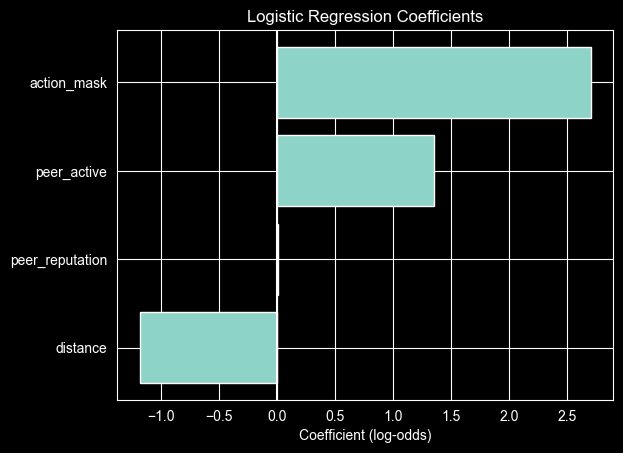

In [21]:
coefs = model.coef_[0]

plt.figure()
plt.barh(feature_cols, coefs)
plt.xlabel("Coefficient (log-odds)")
plt.title("Logistic Regression Coefficients")
plt.axvline(0)
plt.show()

## Probability vs Feature


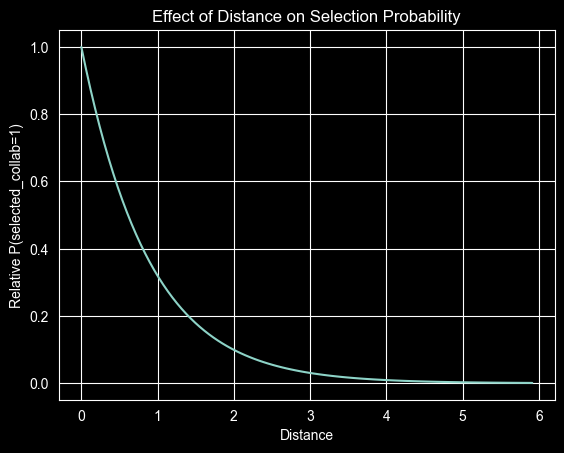

In [36]:
# Range für distance
x_vals = np.linspace(
    collab_df["distance"].min(),
    collab_df["distance"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# realistische Werte setzen (keine fractional binaries)
mean_vals["peer_active"] = 1
mean_vals["action_mask"] = 1

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["distance"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Optional: normalisieren (für bessere Visualisierung)
probs = probs / probs.max()

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Distance")
plt.ylabel("Relative P(selected_collab=1)")
plt.title("Effect of Distance on Selection Probability")
plt.show()

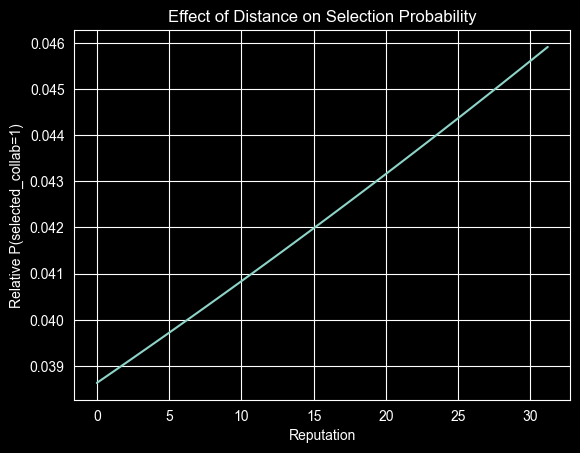

In [40]:
# Range für distance
x_vals = np.linspace(
    collab_df["peer_reputation"].min(),
    collab_df["peer_reputation"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# realistische Werte setzen (keine fractional binaries)
mean_vals["peer_active"] = 1
mean_vals["action_mask"] = 1

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["peer_reputation"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Optional: normalisieren (für bessere Visualisierung)
# probs = probs / probs.max()

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Reputation")
plt.ylabel("Relative P(selected_collab=1)")
plt.title("Effect of Distance on Selection Probability")
# plt.ylim(0, 1)
plt.show()

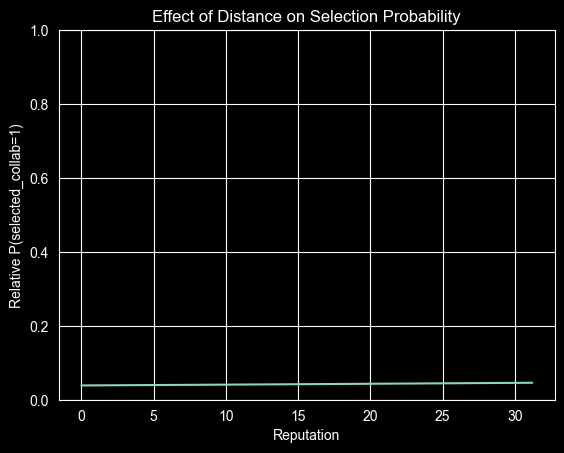

In [41]:
# Range für distance
x_vals = np.linspace(
    collab_df["peer_reputation"].min(),
    collab_df["peer_reputation"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# realistische Werte setzen (keine fractional binaries)
mean_vals["peer_active"] = 1
mean_vals["action_mask"] = 1

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["peer_reputation"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Optional: normalisieren (für bessere Visualisierung)
# probs = probs / probs.max()

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Reputation")
plt.ylabel("Relative P(selected_collab=1)")
plt.title("Effect of Distance on Selection Probability")
plt.ylim(0, 1)
plt.show()

## Standardisierte Koeffizienten

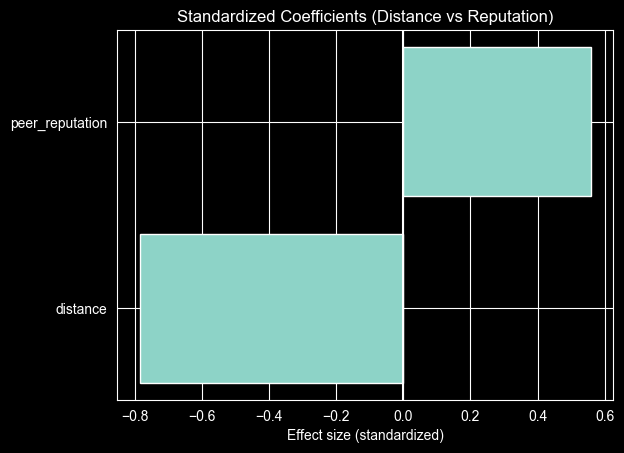

In [42]:
feature_cols = [
    "distance",
    "peer_reputation",
]

features = collab_df[feature_cols]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(features_scaled, target)

plt.figure()
plt.barh(feature_cols, model_scaled.coef_[0])
plt.title("Standardized Coefficients (Distance vs Reputation)")
plt.xlabel("Effect size (standardized)")
plt.axvline(0)
plt.show()

Distance has a stronger per-unit effect on selection probability, while reputation exhibits a comparable standardized effect due to its larger variance across peers.

## Permutation importance: Wie stark beeinflusst jedes Feature die Vorhersage des Modells?

- distance: 0.000318
- peer_reputation: 0.000071
- peer_active: 0.000095
- action_mask: 0.000095

Distance ist klar das wichtigste Feature, aber alle Werte sind klein --> Agent insgesamt nicht super sensitiv auf einzelne Features.

Permutation importance analysis shows that distance is the dominant feature for predicting collaboration decisions, while reputation and other features contribute only marginally.



In [28]:
# Permutation importance
result = permutation_importance(model, features, target, n_repeats=10)

for i, col in enumerate(features.columns):
    print(col, result.importances_mean[i])

distance 0.0003185078909612504
peer_reputation 7.101865136297514e-05
peer_active 9.540889526542529e-05
action_mask 9.540889526542529e-05


In [45]:
# Counterfactual: What if we swap the reputation values of selected and unselected peers?
feature_cols = [
    "distance",
    "peer_reputation",
    "peer_active",
    "action_mask",
]

features = collab_df[feature_cols]
target = collab_df["selected_collab"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

df_test = collab_df.copy()
df_test["peer_reputation"] = np.random.permutation(df_test["peer_reputation"].values)

orig_prob = model.predict_proba(collab_df[feature_cols])[:, 1]
new_prob = model.predict_proba(df_test[feature_cols])[:, 1]

change = np.abs(orig_prob - new_prob).mean()
print("Avg prob change:", change)

Avg prob change: 0.0017119276459652995


In [46]:
feature_cols = [
    "distance",
    "peer_reputation",
    "peer_active",
    "action_mask",
]

features = collab_df[feature_cols]
target = collab_df["selected_collab"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

for col in feature_cols:
    df_test = collab_df.copy()
    df_test[col] = np.random.permutation(df_test[col].values)

    orig_prob = model.predict_proba(collab_df[feature_cols])[:, 1]
    new_prob = model.predict_proba(df_test[feature_cols])[:, 1]

    change = np.abs(orig_prob - new_prob).mean()
    print(col, change)

distance 0.016568415307744312
peer_reputation 0.0017175707085139527
peer_active 0.04831705981480012
action_mask 0.1017424859772338
